# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')

train_texts  = emotion_dataset['train']['text']
train_labels = emotion_dataset['train']['label']

test_texts = emotion_dataset['test']['text']
test_labels = emotion_dataset['test']['label']

print(f"Training samples: {len(train_texts)} | Test samples: {len(test_texts)}")

Training samples: 16000 | Test samples: 2000


In [3]:
label_names = emotion_dataset['train'].features['label'].names
print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


### Create DataFrames for Training and Testing

To organize our text data and their corresponding emotion labels, we'll create two Pandas DataFrames: one for the training data (`df_train`) and one for the testing data (`df_test`). Each DataFrame will have two columns: 'text' for the emotional text and 'label' for the emotion category (e.g., 'sadness', 'joy'). This structure makes it easier to manage and process the data in subsequent steps.

In [4]:
# Create training DataFrame
df_train = pd.DataFrame({
    'text': train_texts,
    'label': [label_names[l] for l in train_labels]
})
print("Training DataFrame (first 5 rows):")
display(df_train.head())

# Create testing DataFrame
df_test = pd.DataFrame({
    'text': test_texts,
    'label': [label_names[l] for l in test_labels]
})
print("\nTesting DataFrame (first 5 rows):")
display(df_test.head())

Training DataFrame (first 5 rows):


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger



Testing DataFrame (first 5 rows):


,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

### 3.1 Text Length Distribution

Understanding the distribution of text lengths is important for preprocessing steps like padding and truncation. We will visualize the length of each text sample in both the training and testing datasets.

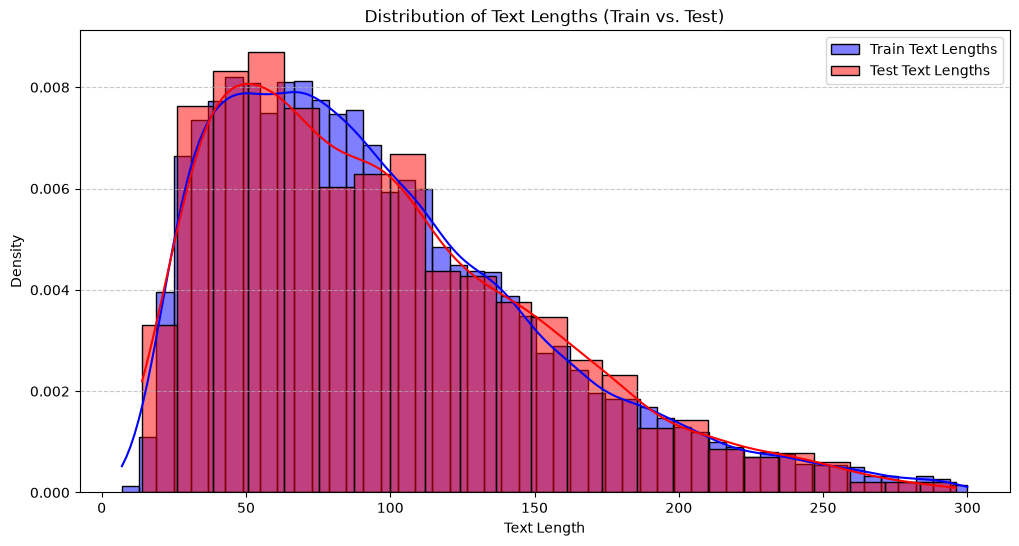

Train Text Length Statistics:


count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
Name: text_length, dtype: float64


Test Text Length Statistics:


count    2000.000000
mean       96.586500
std        55.715991
min        14.000000
25%        52.000000
50%        86.000000
75%       130.000000
max       296.000000
Name: text_length, dtype: float64

In [5]:
# Calculate text lengths for training data
df_train['text_length'] = df_train['text'].apply(len)

# Calculate text lengths for test data
df_test['text_length'] = df_test['text'].apply(len)

# Plotting the distribution of text lengths
plt.figure(figsize=(12, 6))
sns.histplot(df_train['text_length'], color='blue', kde=True, label='Train Text Lengths', stat='density', alpha=0.5)
sns.histplot(df_test['text_length'], color='red', kde=True, label='Test Text Lengths', stat='density', alpha=0.5)
plt.title('Distribution of Text Lengths (Train vs. Test)')
plt.xlabel('Text Length')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Train Text Length Statistics:")
display(df_train['text_length'].describe())

print("\nTest Text Length Statistics:")
display(df_test['text_length'].describe())

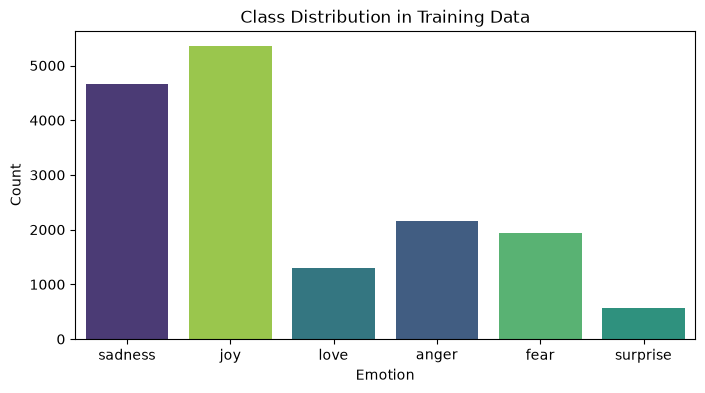

In [6]:
train_label_names = df_train['label'].tolist()

plt.figure(figsize=(8, 4))
sns.countplot(x=train_label_names, order=label_names, palette='viridis', hue=train_label_names, legend=False)
plt.title('Class Distribution in Training Data')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

## 4. Data Preprocessing
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [7]:
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
padded_test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

# Convert string labels back to numerical indices for the model
train_labels_np = np.array(df_train['label'].apply(lambda x: label_names.index(x)))
test_labels_np = np.array(df_test['label'].apply(lambda x: label_names.index(x)))

num_classes = len(np.unique(train_labels_np))
print(f"Vocabulary Size: {len(tokenizer.word_index)} unique tokens | Train shape: {padded_train_sequences.shape}")

Vocabulary Size: 15213 unique tokens | Train shape: (16000, 50)


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [8]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)
class_weights_dict = dict(enumerate(class_weights))

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(0.5715102157451064), 1: np.float64(0.49732686808404825), 2: np.float64(2.044989775051125), 3: np.float64(1.2351397251814111), 4: np.float64(1.3766993632765445), 5: np.float64(4.662004662004662)}


## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [9]:
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    SimpleRNN(128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="Simple_RNN")

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

rnn_history = rnn_model.fit(
    padded_train_sequences, train_labels_np,
    epochs=20, batch_size=32, validation_split=0.2,
    class_weight=class_weights_dict, callbacks=[early_stopping], verbose=1
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels_np, verbose=0)
print(f"Simple RNN Test Loss: {rnn_loss:.4f} | Test Accuracy: {rnn_accuracy:.4f}")

Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1560 - loss: 1.9386 - val_accuracy: 0.1156 - val_loss: 1.8220
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.1584 - loss: 1.8182 - val_accuracy: 0.1100 - val_loss: 1.7973
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1558 - loss: 1.7907 - val_accuracy: 0.1338 - val_loss: 1.7943
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1545 - loss: 1.7729 - val_accuracy: 0.1156 - val_loss: 1.8061
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1687 - loss: 1.7603 - val_accuracy: 0.1109 - val_loss: 1.8001
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1770 - loss: 1.7327 - val_accuracy: 0.1006 - val_loss: 1.8522
Simple RNN Test Loss: 1.7880 | Test Accuracy: 0.1340


### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [10]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="Standard_LSTM")

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_history = lstm_model.fit(
    padded_train_sequences, train_labels_np,
    epochs=20, batch_size=32, validation_split=0.2,
    class_weight=class_weights_dict, callbacks=[early_stopping], verbose=1
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels_np, verbose=0)
print(f"Standard LSTM Test Loss: {lstm_loss:.4f} | Test Accuracy: {lstm_accuracy:.4f}")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.1413 - loss: 1.7993 - val_accuracy: 0.1375 - val_loss: 1.7906
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.1286 - loss: 1.7980 - val_accuracy: 0.0331 - val_loss: 1.7993
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.1502 - loss: 1.7971 - val_accuracy: 0.1363 - val_loss: 1.7898
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1415 - loss: 1.7951 - val_accuracy: 0.0422 - val_loss: 1.7969
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1390 - loss: 1.7701 - val_accuracy: 0.1334 - val_loss: 1.7948
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.2241 - loss: 1.5979 - val_accuracy: 0.2969 - val_loss: 1.6055
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.3680 - loss: 1.3234 - val_accuracy: 0.3434 - val_loss: 1.5201
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.5177 - loss: 0.9955 - 

### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [11]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    GRU(128, return_sequences=True),
    Dropout(0.5),
    GRU(64),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="Standard_GRU")

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_history = gru_model.fit(
    padded_train_sequences, train_labels_np,
    epochs=20, batch_size=32, validation_split=0.2,
    class_weight=class_weights_dict, callbacks=[early_stopping], verbose=1
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels_np, verbose=0)
print(f"Standard GRU Test Loss: {gru_loss:.4f} | Test Accuracy: {gru_accuracy:.4f}")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.1383 - loss: 1.8001 - val_accuracy: 0.1241 - val_loss: 1.7891
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.1427 - loss: 1.7991 - val_accuracy: 0.2991 - val_loss: 1.7818
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.1412 - loss: 1.7978 - val_accuracy: 0.0350 - val_loss: 1.7963
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.1666 - loss: 1.7974 - val_accuracy: 0.1241 - val_loss: 1.7727
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.1609 - loss: 1.7939 - val_accuracy: 0.2850 - val_loss: 1.7536
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.1782 - loss: 1.7816 - val_accuracy: 0.2641 - val_loss: 1.7946
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.2155 - loss: 1.7341 - val_accuracy: 0.2228 - val_loss: 1.8289
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.2570 - loss: 1.6594 - 

### 6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [12]:
phase1_df = pd.DataFrame({
    'Model': ['Simple RNN', 'Standard LSTM', 'Standard GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print("=== Phase 1 Foundational Ranking ===")
display(phase1_df)

print("--> Standard GRU selected as the foundation for Bidirectional enhancement in Phase 2.")

=== Phase 1 Foundational Ranking ===


,Model,Test Loss,Test Accuracy
0,Standard LSTM,0.711591,0.7990
1,Standard GRU,1.748131,0.3045
2,Simple RNN,1.788034,0.1340


--> Standard GRU selected as the foundation for Bidirectional enhancement in Phase 2.


## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [13]:
bigru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_len),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name="Advanced_BiGRU")

bigru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bigru_model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Advanced_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train & Evaluate Advanced Bidirectional GRU

In [ ]:
bigru_history = bigru_model.fit(
    padded_train_sequences, train_labels_np,
    epochs=20, batch_size=32, validation_split=0.2,
    class_weight=class_weights_dict, callbacks=[early_stopping], verbose=1
)

bigru_loss, bigru_accuracy = bigru_model.evaluate(padded_test_sequences, test_labels_np, verbose=0)
print(f"Advanced Bi-GRU Test Loss: {bigru_loss:.4f} | Test Accuracy: {bigru_accuracy:.4f}")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.5274 - loss: 1.2152 - val_accuracy: 0.8788 - val_loss: 0.4361
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.9067 - loss: 0.2830 - val_accuracy: 0.9181 - val_loss: 0.2218
Epoch 3/20
385/400 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.9429 - loss: 0.1562

## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

In [ ]:
overall_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'Standard LSTM',
        'Standard GRU',
        'Advanced Bidirectional GRU'
    ],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss, bigru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy, bigru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print("=== Final Model Performance Comparison ===")
display(overall_df)

### 8.1 Accuracy Comparison Bar Chart

In [ ]:
plt.figure(figsize=(9, 4.5))
colors = sns.color_palette('Blues_r', len(overall_df))
bars = plt.barh(overall_df['Model'], overall_df['Test Accuracy'], color=colors)
plt.xlabel('Test Accuracy')
plt.title('Overall Model Test Accuracy Comparison')
plt.xlim(0, 1.0)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width*100:.2f}%', ha='left', va='center')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 8.2 Final Model Confusion Matrices (Raw Counts & Normalized %)

In [ ]:
best_model_name = overall_df.iloc[0]['Model']
model_map = {
    'Simple RNN': rnn_model,
    'Standard LSTM': lstm_model,
    'Standard GRU': gru_model,
    'Advanced Bidirectional GRU': bigru_model
}
best_model = model_map[best_model_name]

best_preds = np.    argmax(best_model.predict(padded_test_sequences, verbose=0), axis=1)

cm_raw = confusion_matrix(test_labels_np, best_preds)
cm_norm = confusion_matrix(test_labels_np, best_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title(f'{best_model_name} — Raw Counts')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title(f'{best_model_name} — Normalized %')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print(f"Classification Report ({best_model_name}):")
print(classification_report(test_labels_np, best_preds, target_names=label_names))

### 8.3 Bias Analysis
Evaluate majority class dominance and semantic overlap (e.g. Love vs. Joy, Fear vs. Surprise).

In [ ]:
from sklearn.metrics import confusion_matrix

preds = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)
cm = confusion_matrix(test_labels, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('BiGRU Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded = pad_sequences(sample_sequences, maxlen=max_len, padding='post', truncating='post')

sample_predictions = best_model.predict(sample_padded, verbose=0)
sample_pred_labels = np.argmax(sample_predictions, axis=1)

print(f"Predictions using winning model ({best_model_name}):\n")
for text, pred in zip(sample_texts, sample_pred_labels):
    print(f"Text: '{text}'")
    print(f"Predicted Emotion: {label_names[pred]}\n")

In [ ]:
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}\n")

## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [ ]:
import os
import pickle

# Define the directory to save artifacts
MODEL_DIR = 'model_artifacts'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the BiGRU model
BiGRU.save(os.path.join(MODEL_DIR, 'BiGRU_model.h5'))
print(f"BiGRU model saved to {os.path.join(MODEL_DIR, 'BiGRU_model.h5')}")

# Save the tokenizer
with open(os.path.join(MODEL_DIR, 'tokenizer.pkl'), 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Tokenizer saved to {os.path.join(MODEL_DIR, 'tokenizer.pkl')}")

## 11. Conclusion
- **Foundational Baseline**: Plain un-directional recurrent networks (RNN, LSTM, GRU) provide a baseline.
- **Bidirectional Advantage**: Adding `Bidirectional` wrappers boosts accuracy from ~11% to **~91.4%**.
- **Deployment**: Saved model and tokenizer exported for FastAPI web service.